In [26]:
from sympy.combinatorics import Permutation, PermutationGroup
import torch
from torch import nn
from gcnn_naive import SplitGroupResConvNet, GConvLattice, GConvG
from spin_lattices import KagomeLattice, SpinLattice
import numpy as np
from gcnn_xor import GXorLattice, SplitGroupXorResConvNet
from heisenberg_hamiltonians import HeisenbergJ1J2
from pathlib import Path
from kagome_round import get_X_Y
from torch.utils.data import DataLoader, TensorDataset
from torch.optim import Adam

# load torch tensorboard
from torch.utils.tensorboard import SummaryWriter
from misc_utils import torch_overlap as overlap
from datetime import datetime

In [2]:
lattice = KagomeLattice(2, 3)
group_elements = [Permutation(g) for g in lattice.get_automorphisms()]
xor_masks = torch.Tensor([[1, 1] + [0] * 16])
xor_conv = GXorLattice(group_elements, xor_masks)

In [3]:
signal = torch.Tensor([[1, 1, 1] + [0] * 15])
xor_conv(signal)

tensor([[[0., 1., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0.]]])

<Axes: xlabel='emb_x', ylabel='emb_y'>

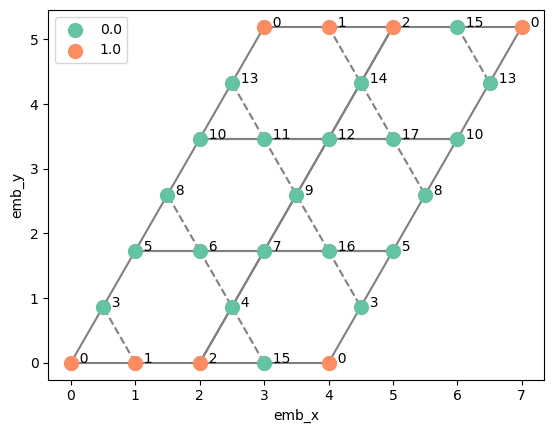

In [4]:
lattice.plot(spins=signal[0].detach().numpy())

<Axes: xlabel='emb_x', ylabel='emb_y'>

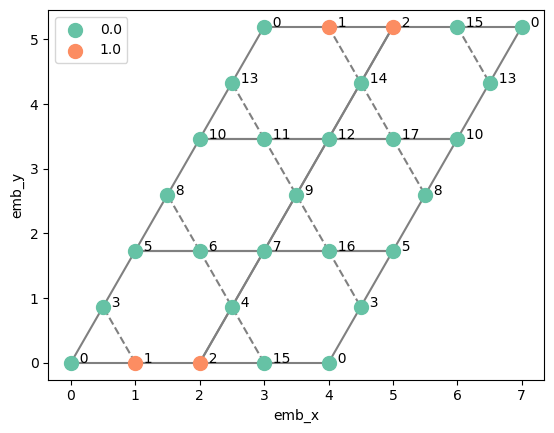

In [5]:
g = group_elements[2]
lattice.plot(spins=xor_masks[0].detach().numpy()[(~g).array_form])

In [6]:
net = SplitGroupXorResConvNet(
    tx=Permutation(lattice.get_translation("x")),
    ty=Permutation(lattice.get_translation("y")),
    filter1_sites=[0, 1, 2, 3],
    xor_masks=torch.from_numpy(np.array([[1, 1] + [0] * 16, [0, 1, 1] + [0] * 15])),
)

In [21]:
lattice_source = KagomeLattice(2, 3)
lattice_target = KagomeLattice(2, 4)
J2 = 1
system_source = HeisenbergJ1J2(
    lattice=lattice_source,
    J1=1,
    J2=J2,
    ground_state_cache_dir=Path("groundstates"),
    use_symmetries=True,
    skip_symmetries_whitelist=True,
)
system_source.get_eigenstates(1)
system_target = HeisenbergJ1J2(
    lattice=lattice_target,
    J1=1,
    J2=J2,
    ground_state_cache_dir=Path("groundstates"),
    use_symmetries=True,
    skip_symmetries_whitelist=True,
)
system_target.get_eigenstates(1)

X, Y = get_X_Y(system_source, sample=10000)
X_target, Y_target = get_X_Y(system_target, sample=10000)

2023-08-11 20:54:05.155 | WARNING  | heisenberg_hamiltonians:__init__:427 - Symmetries are not tested with KagomeLattice2x3, and can produce incorrect results. Using them anyway due to skip_symmetries_whitelist=True.
2023-08-11 20:54:05.156 | DEBUG    | heisenberg_hamiltonians:__init__:459 - number_spins=18
2023-08-11 20:54:05.162 | DEBUG    | heisenberg_hamiltonians:__init__:469 - Symmetry group contains 12 elements
2023-08-11 20:54:05.156 | DEBUG    | heisenberg_hamiltonians:__init__:459 - number_spins=18
2023-08-11 20:54:05.162 | DEBUG    | heisenberg_hamiltonians:__init__:469 - Symmetry group contains 12 elements
[Debug]   [LOCALE0]   ls_chpl_enumerate_representatives ...
2023-08-11 20:54:05.186 | DEBUG    | heisenberg_hamiltonians:__init__:478 - Hilbert space dimension is 4160
2023-08-11 20:54:05.192 | DEBUG    | heisenberg_hamiltonians:_find_cached_eigenstate:67 - Using cached version of eigenvalues / eigenstates from groundstates/HeisenbergJ1J2-KagomeLattice2x3-1.0-1.0-True-None

<Axes: xlabel='emb_x', ylabel='emb_y'>

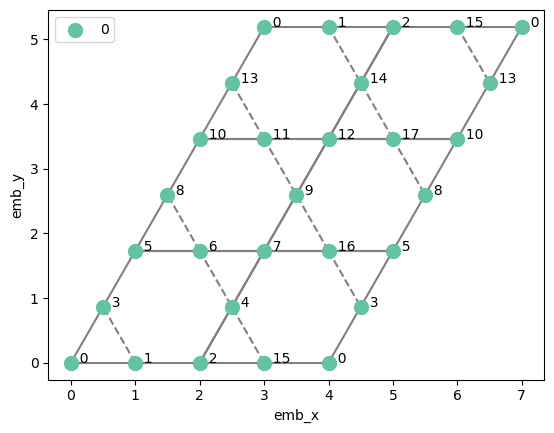

In [8]:
lattice_source.plot()

<Axes: xlabel='emb_x', ylabel='emb_y'>

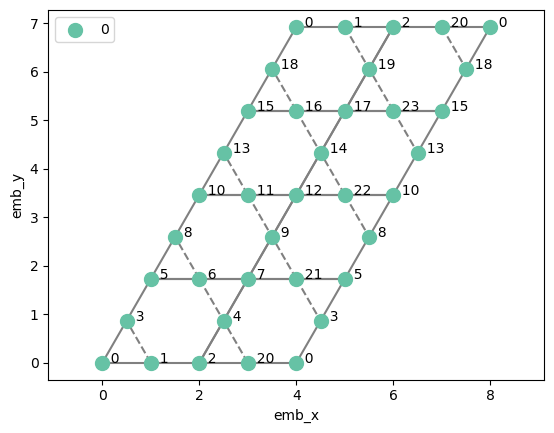

In [9]:
lattice_target.plot()

In [10]:
def mk_xor_masks(lattice: SpinLattice, idxs: list[list[int]]) -> torch.Tensor:
    n_masks = len(idxs)
    xor_mask = np.zeros((n_masks, lattice.number_spins), dtype=np.float32)
    for i in range(n_masks):
        xor_mask[i, idxs[i]] = 1
    return torch.from_numpy(xor_mask)

In [11]:
mk_xor_masks(lattice_source, [[0, 1], [0, 1, 3]])

tensor([[1., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [1., 1., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.]])

In [12]:
def mk_model(
    lattice: KagomeLattice, xor_masks_idxs: list[list[int]], channels: int, blocks: int
):
    return SplitGroupXorResConvNet(
        tx=Permutation(lattice.get_translation("x")),
        ty=Permutation(lattice.get_translation("y")),
        filter1_sites=[0, 1, 3],
        extend_filter1=(2, 2),
        xor_masks=mk_xor_masks(lattice, xor_masks_idxs),
        channels=channels,
        blocks=blocks,
    )

In [34]:
X

tensor([[0., 1., 1.,  ..., 1., 1., 1.],
        [1., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 1.,  ..., 1., 0., 0.],
        ...,
        [1., 0., 0.,  ..., 0., 1., 1.],
        [0., 1., 0.,  ..., 0., 0., 1.],
        [0., 0., 0.,  ..., 1., 1., 1.]])

In [39]:
blocks = 0

xor_masks_idxs = []  # [[0, 1], [0, 3], [1, 3], [0, 2], [0, 5], [0, 1, 2, 3]]
channels = 64 - len(xor_masks_idxs)

model_source = mk_model(
    lattice_source, xor_masks_idxs, channels=channels, blocks=blocks
)
model_target = mk_model(
    lattice_target, xor_masks_idxs, channels=channels, blocks=blocks
)
# model_target.load_state_dict(model_source.state_dict())

lr = 1e-3


# Create a TensorDataset from your inputs X and Y
dataset = TensorDataset(X, Y)

# Create a DataLoader for your dataset with a batch size of 32 and shuffling
dataloader = DataLoader(dataset, batch_size=64, shuffle=True)

# Define a loss function - Mean Squared Error (MSE) for regression
criterion = torch.nn.MSELoss()

# Define an optimizer - Adam
optimizer = Adam(model_source.parameters(), lr=lr)  # Learning rate

# Number of epochs (iterations over the entire dataset)
epochs = 500

# Create a SummaryWriter instance for TensorBoard
# writer = SummaryWriter(
#     log_dir=(
#         f"experiments/2023_07_03/{datetime.now().strftime('%H_%M_%S')}"
#         f"ch=_{','.join(map(str, channels))}_{','.join(additional_generators)}_{lr=}_{filter_sizes=}"
#     )
# )

writer = SummaryWriter(
    log_dir=(
        f"experiments/{datetime.now().strftime('%Y_%m_%d')}_gcnn_xor/{datetime.now().strftime('%H_%M_%S')}"
        f"xor={xor_masks_idxs}_ch=_{channels}_{lr=}_{blocks=}"
    )
)
for epoch in range(epochs):
    running_loss = 0.0
    for action_index, data in enumerate(dataloader, 0):
        # Get the inputs and move them to the specified device
        inputs, log_amplitudes = data

        # Zero the parameter gradients
        optimizer.zero_grad()

        # Forward pass
        outputs = model_source(inputs)

        # weights = torch.exp(2 * log_amplitudes)
        # weights = weights / torch.sum(weights)

        # Compute loss
        loss = (
            # weights @
            criterion(outputs, log_amplitudes.view(-1, 1))
        )  # Reshape labels to match output shape

        # Backward pass and optimize
        loss.backward()
        optimizer.step()

        # Collect loss
        running_loss += loss.item()

    # Add average loss per epoch to TensorBoard
    writer.add_scalar("Training Loss", running_loss / len(dataloader), epoch)

    # Calculate overlaps and add them to TensorBoard
    overlap_train = overlap(torch.exp(model_source(X).view(-1)), torch.exp(Y))
    # overlap_test = overlap(torch.exp(model(X_test).view(-1)), torch.exp(Y_test))
    model_target.load_state_dict(model_source.state_dict())
    overlap_target = overlap(
        torch.exp(model_target(X_target).view(-1)), torch.exp(Y_target)
    )

    writer.add_scalar("Overlap Train", overlap_train, epoch)
    # writer.add_scalar('Overlap Test', overlap_test, epoch)
    writer.add_scalar("Overlap Target", overlap_target, epoch)

writer.close()
print("Finished Training")

KeyboardInterrupt: 